In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_file=pd.read_csv("Telco_Custome.csv")
data_file

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
data_file.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
data_file['TotalCharges']=pd.to_numeric(data_file['TotalCharges'], errors='coerce')

In [6]:
#missing values in total charges
data_file['TotalCharges'].isnull().sum()

11

In [7]:
data_file['TotalCharges']=data_file['TotalCharges'].fillna(0)

In [8]:
data_file[['tenure', 'MonthlyCharges','TotalCharges']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


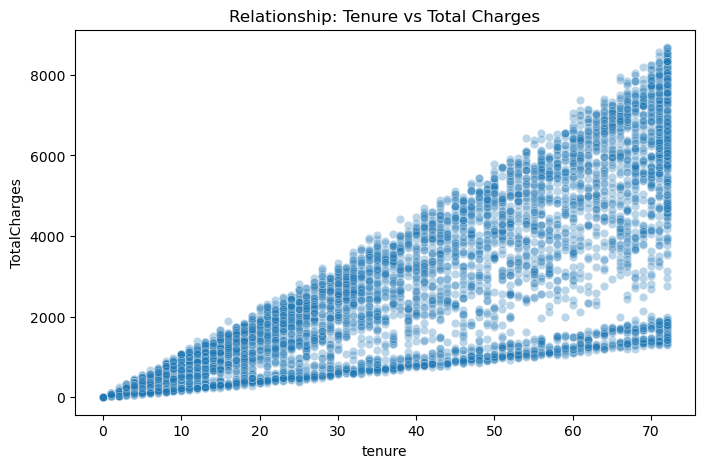

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='tenure', y='TotalCharges', data=data_file, alpha=0.3)
plt.title('Relationship: Tenure vs Total Charges')
plt.show()

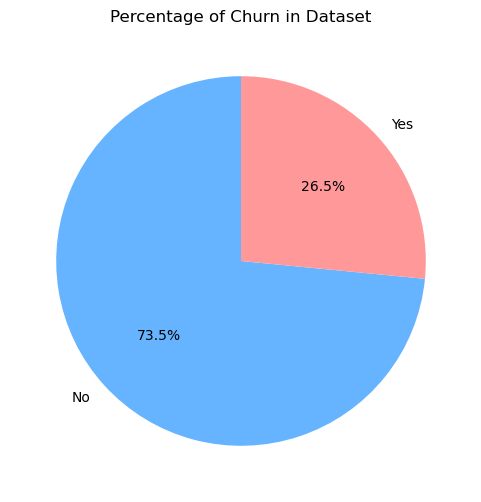

In [24]:
#pie chart to see the proportion of churn
plt.figure(figsize=(6, 6))
data_file['Churn'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Percentage of Churn in Dataset')
plt.ylabel('')
plt.savefig('Churn_percentage', bbox_inches='tight')
plt.show()

C:\Users\Komal\AppData\Local\Temp\ipykernel_10604\3033007104.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_file.loc[data_file['Churn'] == 'No', 'tenure'], label='Loyal', shade=True)
C:\Users\Komal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Komal\AppData\Local\Temp\ipykernel_10604\3033007104.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_file.loc[data_file['Churn'] == 'Yes', 'tenure'], label='Churned', shade=True)
C:\Users\Komal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na

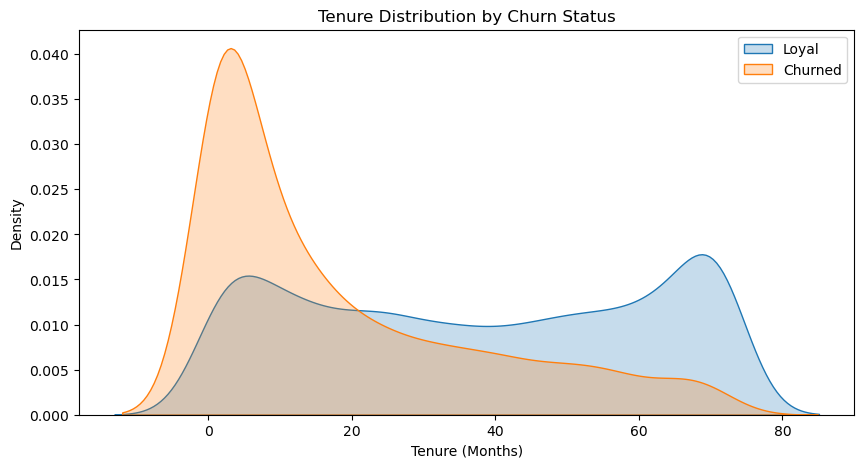

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data_file.loc[data_file['Churn'] == 'No', 'tenure'], label='Loyal', shade=True)
sns.kdeplot(data_file.loc[data_file['Churn'] == 'Yes', 'tenure'], label='Churned', shade=True)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.legend()
plt.savefig('tenure_distribution', bbox_inches='tight')
plt.show()

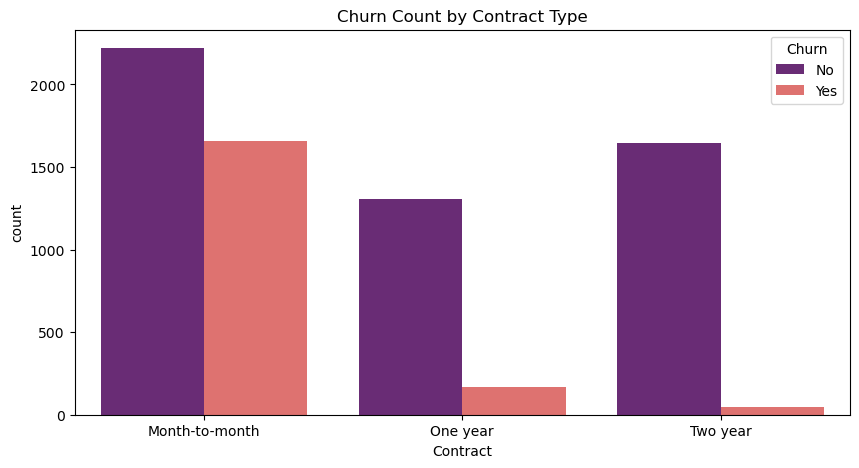

In [26]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=data_file, palette='magma')
plt.title('Churn Count by Contract Type')
plt.savefig('churnbycontract', bbox_inches='tight')
plt.show()

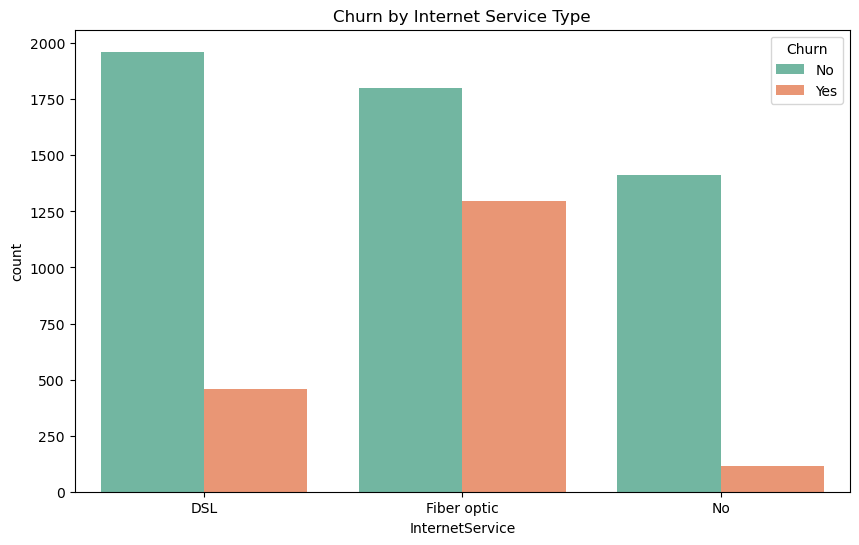

In [27]:
# Analyzing Internet Service vs Churn
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=data_file, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.savefig('churnby_internetservice', bbox_inches='tight')
plt.show()

In [15]:
data_file['Churn_Binary'] = data_file['Churn'].map({'Yes': 1, 'No': 0})

In [16]:
numeric_df = data_file.select_dtypes(include=[np.number])

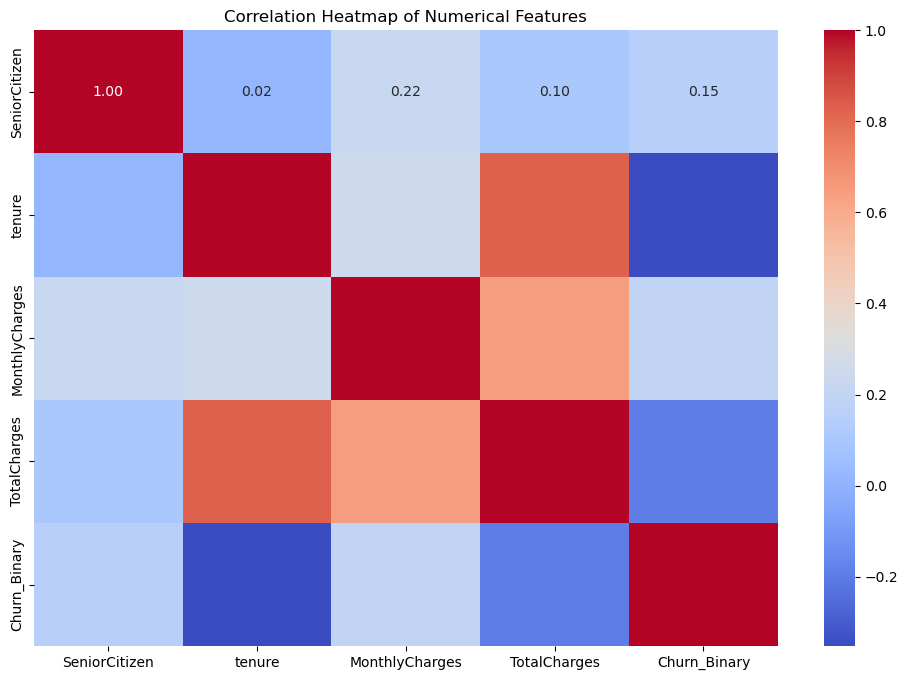

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('feature_correlation', bbox_inches='tight')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Drop ID as it's not a predictor
X = data_file.drop(['customerID', 'Churn', 'Churn_Binary'], axis=1)
y = data_file['Churn_Binary']

# Convert categorical variables into dummy variables
X = pd.get_dummies(X)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Confusion Matrix:
[[947  89]
 [200 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



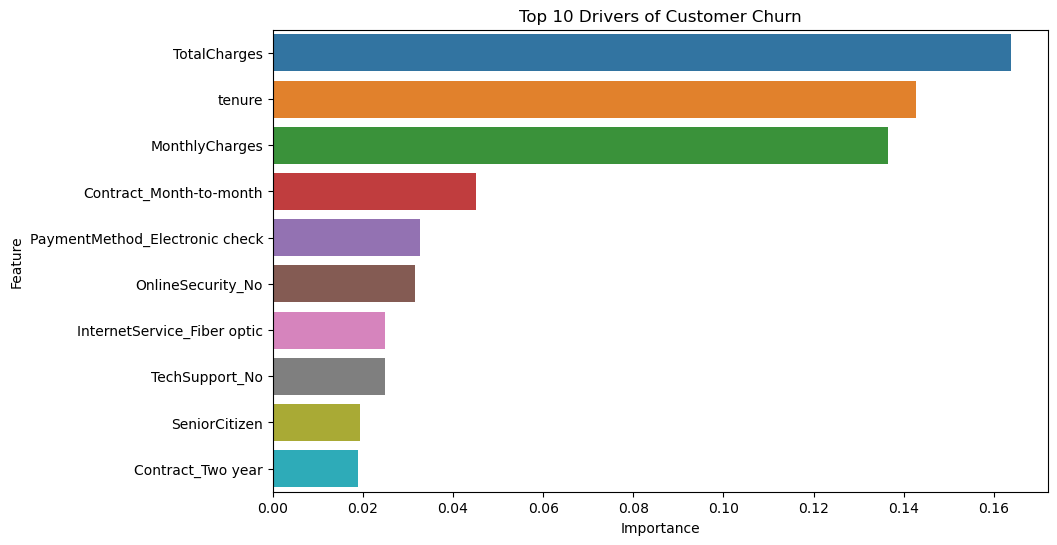

In [29]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Drivers of Customer Churn')
plt.savefig('Top churn drivers', bbox_inches='tight')
plt.show()

# Summary: Telco Churn Analysis

## 1. The Business Problem

The company is experiencing a 26.5% annual churn rate. Analysis shows that customer loss is not random.
It is heavily concentrated in the first six months of service and among those on month-to-month contracts.

## 2. Key Analytical Insights
* A KDE (Kernel Density Estimate) analysis revealed a critical "danger zone" in the first 5 months. If a customer remains past 12 months, their likelihood of churning drops by over 60%.

* Fiber Optic users churn at a much higher rate than DSL users. Despite being a "premium" service, it shows the highest dissatisfaction.

* Customers without Tech Support or Online Security are significantly more likely to leave. These features act as "sticky" services that increase retention.

## 3. Predictive Model Performance
Using a Random Forest Classifier, we achieved an overall accuracy of 79%.
* Precision (66%): Two out of three customers flagged by the model will actually churn.
* Top Predictors: Total Charges, Tenure, Monthly Charges, and Month-to-month contracts were identified as the primary drivers of churn.

## 4. Strategic Recommendations
* Contract Migration: Introduce a "First Year Loyalty" discount to move customers from Month-to-Month to 1-Year contracts.

* Proactive Support: Target Fiber Optic users with a complimentary "Service Health Check" or "Tech Support" trial in 2 month to bridge the "danger zone."

* Automated Flagging: Deploy the model to the customer service dashboard to highlight "at-risk" customers for retention offers during support calls.